# Import Library

In [ ]:
# ==========================================================
# 🌍 EMISI KARBON — EDA → Residual Learning (Hybrid) → Evaluasi → Simpan → Inference
# ==========================================================
# !pip install pandas numpy seaborn matplotlib scikit-learn joblib

import os, json, re, warnings, io
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestRegressor
import joblib

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("crest")

# Import Dataset

In [ ]:
# ==========================================================
# 0) KONFIGURASI KOLOM & KONSTANTA (SAMAKAN DENGAN EXCEL)
# ==========================================================
TARGET = "Emisi Carbon"
COLS = {
    "usia": "Usia",
    "gender": "Jenis Kelamin",
    "prov": "Provinsi Domisi",   # <- perhatikan ejaannya
    "transport": "Transportasi",
    "km": "Jarak Tempuh Rata-Rata Per Bulan (km)",
    "bags": "Jumlah Kantong Sampah per Minggu",
    "kwh": "Konsumsi listrik per bulan (kWh)"
}

FE_LISTRIK = 0.794            # kg CO2/kWh
WEEKS_PER_MONTH = 4.0         # jika Excel pakai 4.2857, ubah di sini
FE_TR_G_PER_KM = {            # g CO2/km
    "Motor": 74,
    "Mobil Bensin": 246,
    "Mobil Listrik": 6,
    "Transportasi Umum": 0    # ubah jika perlu
}

# ==========================================================
# 1) PENGUMPULAN DATA (UPLOAD TRAIN SET DENGAN KOLOM TARGET)
# ==========================================================
print("📤 Upload file LATIH (punya kolom 'Emisi Carbon'), .csv atau .xlsx")
uploaded = files.upload()
fname = list(uploaded.keys())[0]

if fname.lower().endswith(".csv"):
    df = pd.read_csv(io.BytesIO(uploaded[fname]), sep=";")  # Excel Indo sering pakai ';'
else:
    df = pd.read_excel(io.BytesIO(uploaded[fname]))

print(f"✅ Dibaca: {fname} | shape={df.shape}")
display(df.head(3))


📤 Upload file LATIH (punya kolom 'Emisi Carbon'), .csv atau .xlsx


Saving Dataset Capstone Project siap pakai.csv to Dataset Capstone Project siap pakai.csv
✅ Dibaca: Dataset Capstone Project siap pakai.csv | shape=(1915, 8)


,Usia,Jenis Kelamin,Provinsi Domisi,Transportasi,Jarak Tempuh Rata-Rata Per Bulan (km),Jumlah Kantong Sampah per Minggu,Konsumsi listrik per bulan (kWh),Emisi Carbon
0,> 40 Tahun,Laki-Laki,Bengkulu,Jalan Kaki,0,7,271,"313,174"
1,20-30 Tahun,Laki-Laki,Papua Tengah,Sepeda,115,4,428,"395,832"
2,30-40 Tahun,Laki-Laki,Nanggroe Aceh Darussalam,Sepeda,107,10,130,"243,22"


# Pra Pemrosesan Data

In [ ]:
# ==========================================================
# 2) CLEANING RINGAN
# ==========================================================
def to_float(s: pd.Series) -> pd.Series:
    return pd.to_numeric(
        s.astype(str).str.replace(",", ".", regex=False).str.replace(r"[^0-9.\-]","", regex=True),
        errors="coerce"
    )

# pastikan numerik bersih
for c in [COLS["km"], COLS["bags"], COLS["kwh"], TARGET]:
    if c in df.columns:
        df[c] = to_float(df[c])

# normalisasi teks kategori (trim spasi)
def norm(s): return re.sub(r"\s+"," ", str(s).strip())
for c in [COLS["usia"], COLS["gender"], COLS["prov"], COLS["transport"]]:
    if c in df.columns:
        df[c] = df[c].map(norm)

# buang baris tanpa target/komponen penting
df = df.dropna(subset=[TARGET, COLS["km"], COLS["bags"], COLS["kwh"]]).reset_index(drop=True)

print("\n✅ Dtypes setelah cleaning:")
print(df.dtypes)


✅ Dtypes setelah cleaning:
Usia                                      object
Jenis Kelamin                             object
Provinsi Domisi                           object
Transportasi                              object
Jarak Tempuh Rata-Rata Per Bulan (km)      int64
Jumlah Kantong Sampah per Minggu           int64
Konsumsi listrik per bulan (kWh)           int64
Emisi Carbon                             float64
dtype: object


In [ ]:
# ==========================================================
# 3) HITUNG EMISI MANUAL (REPLIKASI RUMUS EXCEL)
#    em_manual = listrik*0.794 + km*faktor_kendaraan/1000 + sampah*3.5*WEEKS_PER_MONTH
# ==========================================================
def gpkm(t): return FE_TR_G_PER_KM.get(norm(t), 0)

df["emisi_listrik"]   = df[COLS["kwh"]] * FE_LISTRIK
df["emisi_transport"] = df[COLS["km"]] * df[COLS["transport"]].map(gpkm).fillna(0) / 1000.0
df["emisi_sampah"]    = df[COLS["bags"]] * 3.5 * WEEKS_PER_MONTH
df["emisi_manual"]    = df["emisi_listrik"] + df["emisi_transport"] + df["emisi_sampah"]

# Exploratory Data Analysis

In [ ]:
# ==========================================================
# 4) EDA: Statistik, Korelasi, Insight Visual
# ==========================================================
print("\n📊 Statistik numerik:")
display(df[[TARGET,"emisi_manual","emisi_listrik","emisi_transport","emisi_sampah",COLS["km"],COLS["kwh"],COLS["bags"]]].describe().T)

print("\n❓ Missing values per kolom:")
display(df.isna().sum().sort_values(ascending=False))


📊 Statistik numerik:


,count,mean,std,min,25%,50%,75%,max
Emisi Carbon,1915.0,637.542441,267.901666,134.898,416.686,622.118,870.434,1199.082
emisi_manual,1915.0,637.542441,267.901666,134.898,416.686,622.118,870.434,1199.082
emisi_listrik,1915.0,524.016781,259.551177,82.576,309.660,526.422,747.551,950.418
emisi_transport,1915.0,41.149680,75.657041,0.000,0.000,0.000,49.200,291.756
emisi_sampah,1915.0,72.375979,40.782583,14.000,42.000,70.000,112.000,140.000
Jarak Tempuh Rata-Rata Per Bulan (km),1915.0,408.819321,382.619984,0.000,60.000,295.000,684.000,1487.000
Konsumsi listrik per bulan (kWh),1915.0,659.970757,326.890651,104.000,390.000,663.000,941.500,1197.000
Jumlah Kantong Sampah per Minggu,1915.0,5.169713,2.913042,1.000,3.000,5.000,8.000,10.000



❓ Missing values per kolom:


,0
Usia,0
Jenis Kelamin,0
Provinsi Domisi,0
Transportasi,0
Jarak Tempuh Rata-Rata Per Bulan (km),0
Jumlah Kantong Sampah per Minggu,0
Konsumsi listrik per bulan (kWh),0
Emisi Carbon,0
emisi_listrik,0
emisi_transport,0


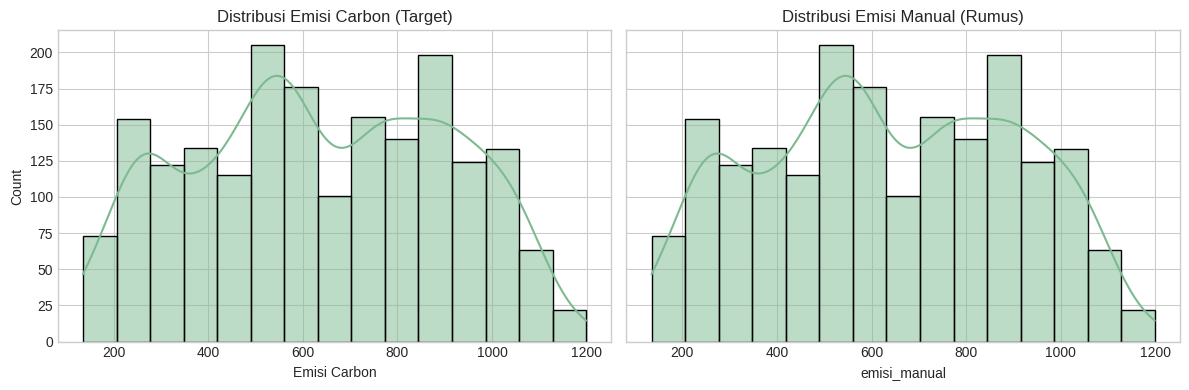

In [ ]:
# distribusi target & manual
fig, ax = plt.subplots(1,2, figsize=(12,4), sharey=True)
sns.histplot(df[TARGET], kde=True, ax=ax[0]); ax[0].set_title("Distribusi Emisi Carbon (Target)")
sns.histplot(df["emisi_manual"], kde=True, ax=ax[1]); ax[1].set_title("Distribusi Emisi Manual (Rumus)")
plt.tight_layout(); plt.show()

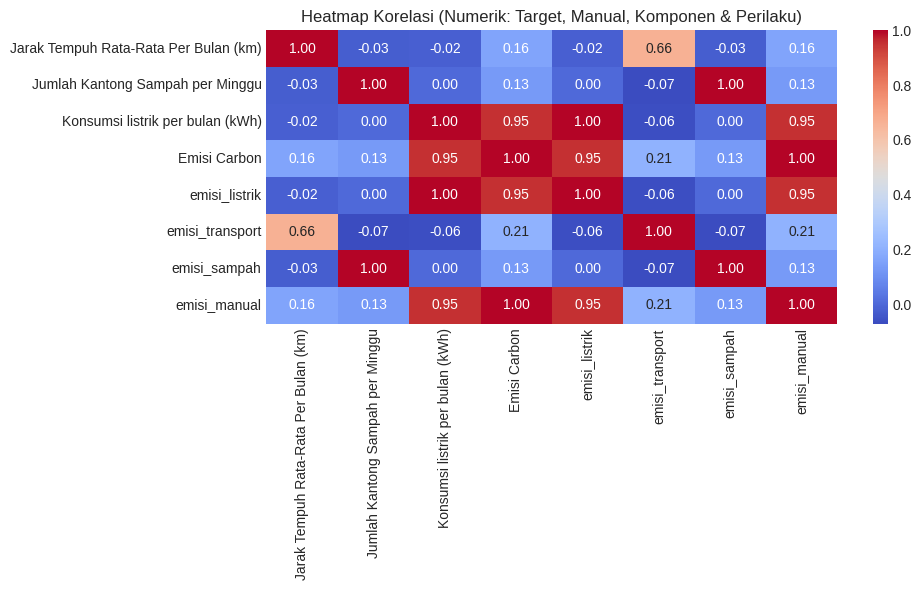

In [ ]:
# korelasi numerik
num_only = df.select_dtypes(include=[np.number])
if num_only.shape[1] >= 2:
    plt.figure(figsize=(10,6))
    sns.heatmap(num_only.corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Heatmap Korelasi (Numerik: Target, Manual, Komponen & Perilaku)")
    plt.tight_layout(); plt.show()


🔎 Insight per kategori (target = Emisi Carbon):


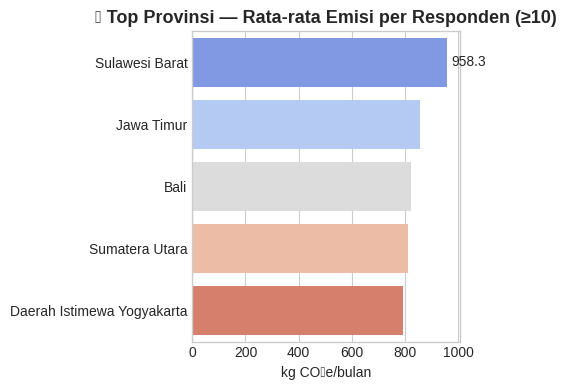

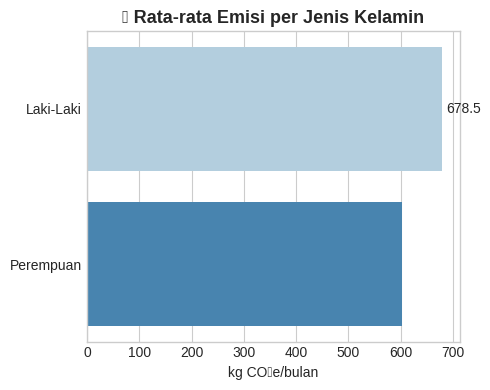

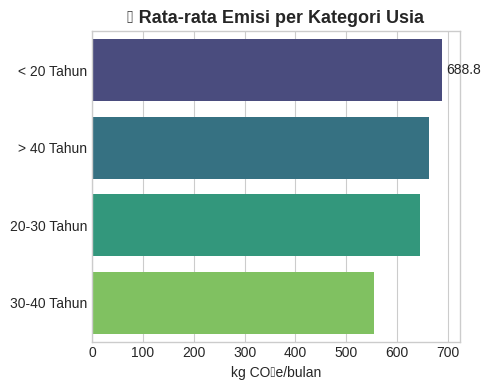

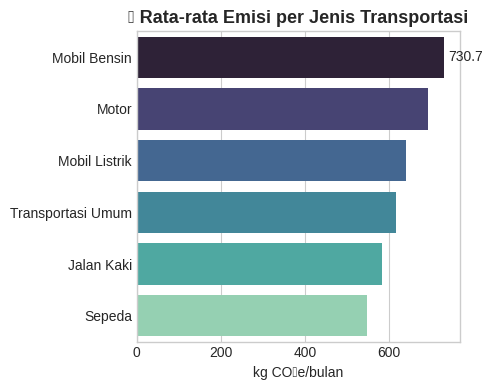

In [ ]:
# Insight visual (mean per kategori)
def bar_mean(df, by, target=TARGET, top=None, min_n=1, title="", palette="coolwarm"):
    agg = (df.groupby(by)[target]
             .agg(['mean','median','count'])
             .rename(columns={'mean':'Rata-rata','median':'Median','count':'Responden'})
             .sort_values('Rata-rata', ascending=False))
    agg = agg.query("Responden >= @min_n")
    if top: agg = agg.head(top)
    plt.figure(figsize=(5, max(4, 0.4*len(agg))))
    ax = sns.barplot(data=agg, x="Rata-rata", y=agg.index, palette=sns.color_palette(palette, len(agg)))
    ax.bar_label(ax.containers[0], fmt="%.1f", padding=3)
    plt.title(title, fontsize=13, weight='bold'); plt.xlabel("kg CO₂e/bulan"); plt.ylabel("")
    plt.tight_layout(); plt.show()
    return agg

print("\n🔎 Insight per kategori (target = Emisi Carbon):")
prov_top = bar_mean(df, COLS["prov"], top=5, min_n=10, title="🌆 Top Provinsi — Rata-rata Emisi per Responden (≥10)")
gender_mean = bar_mean(df, COLS["gender"], title="👥 Rata-rata Emisi per Jenis Kelamin", palette="Blues")
usia_mean = bar_mean(df, COLS["usia"], title="📊 Rata-rata Emisi per Kategori Usia", palette="viridis")
trans_mean = bar_mean(df, COLS["transport"], title="🚗 Rata-rata Emisi per Jenis Transportasi", palette="mako")

# Split dan Training

In [ ]:
# ==========================================================
# 5) RESIDUAL LEARNING: y_residual = TARGET - emisi_manual
# ==========================================================
df["residual"] = df[TARGET] - df["emisi_manual"]

# Preparation fitur
num_cols = [COLS["km"], COLS["bags"], COLS["kwh"]]   # perilaku numerik mentah
cat_cols = [COLS["usia"], COLS["gender"], COLS["prov"], COLS["transport"]]

print("\n🧱 Numerik      :", num_cols)
print("🏷️ Kategorikal :", cat_cols)

X = df[num_cols + cat_cols].copy()
y = df["residual"].astype(float)


🧱 Numerik      : ['Jarak Tempuh Rata-Rata Per Bulan (km)', 'Jumlah Kantong Sampah per Minggu', 'Konsumsi listrik per bulan (kWh)']
🏷️ Kategorikal : ['Usia', 'Jenis Kelamin', 'Provinsi Domisi', 'Transportasi']


In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ColumnTransformer
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

In [ ]:
# Model residual
residual_model = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=600, random_state=42, n_jobs=-1
    ))
])

# Train
residual_model.fit(X_train, y_train)
y_pred_res = residual_model.predict(X_test)

# Evaluasi Model


📈 Evaluasi Residual (harus kecil):
Residual  R²=-0.0002 | MAE=0.00 | RMSE=0.00
📈 Evaluasi TOTAL Emisi (Target utama):
Total Emisi  R²=1.0000 | MAE=0.00 | RMSE=0.00
CV R² residual: -0.0013 ± 0.0013

🎯 Akurasi Klasifikasi Level Emisi (low=150, high=782): 1.000
              precision    recall  f1-score   support

      Rendah      1.000     1.000     1.000         6
      Sedang      1.000     1.000     1.000       261
      Tinggi      1.000     1.000     1.000       116

    accuracy                          1.000       383
   macro avg      1.000     1.000     1.000       383
weighted avg      1.000     1.000     1.000       383



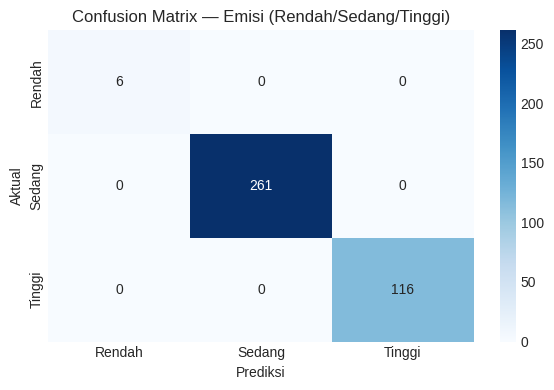

In [ ]:
# ==========================================================
# 6) EVALUASI — Residual & Total Emisi
# ==========================================================
def eval_print(y_true, y_pred, name=""):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}  R²={r2:.4f} | MAE={mae:.2f} | RMSE={rmse:.2f}")
    return r2, mae, rmse

print("\n📈 Evaluasi Residual (harus kecil):")
eval_print(y_test, y_pred_res, "Residual")

# total = manual + residual
y_true_total = (df.loc[y_test.index, "emisi_manual"] + y_test).values
y_pred_total = (df.loc[y_test.index, "emisi_manual"] + y_pred_res).values

print("📈 Evaluasi TOTAL Emisi (Target utama):")
eval_print(y_true_total, y_pred_total, "Total Emisi")

# Cross-validation residual
cv = cross_val_score(residual_model, X, y, cv=5, scoring="r2", n_jobs=-1)
print(f"CV R² residual: {cv.mean():.4f} ± {cv.std():.4f}")

# Confusion matrix level emisi (Rendah/Sedang/Tinggi) berbasis total
LOW, HIGH = 150.0, float(np.percentile(df[TARGET], 67))
def label_emisi(v):
    if v < LOW:  return "Rendah"
    if v < HIGH: return "Sedang"
    return "Tinggi"

y_true_cls = [label_emisi(v) for v in y_true_total]
y_pred_cls = [label_emisi(v) for v in y_pred_total]
labels = ["Rendah","Sedang","Tinggi"]
cm = confusion_matrix(y_true_cls, y_pred_cls, labels=labels)
acc = accuracy_score(y_true_cls, y_pred_cls)
print(f"\n🎯 Akurasi Klasifikasi Level Emisi (low={LOW:.0f}, high={HIGH:.0f}): {acc:.3f}")
print(classification_report(y_true_cls, y_pred_cls, target_names=labels, digits=3))
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Prediksi"); plt.ylabel("Aktual")
plt.title("Confusion Matrix — Emisi (Rendah/Sedang/Tinggi)")
plt.tight_layout(); plt.show()

# Simpan Model

In [ ]:
# ==========================================================
# 7) SIMPAN ARTEFAK (untuk DEPLOY HYBRID)
# ==========================================================
os.makedirs("artifacts_improved", exist_ok=True)
joblib.dump(residual_model, "artifacts_improved/residual_model.pkl")
with open("artifacts_improved/formula_config.json","w", encoding="utf-8") as f:
    json.dump({
        "FE_LISTRIK": FE_LISTRIK,
        "WEEKS_PER_MONTH": WEEKS_PER_MONTH,
        "FE_TR_G_PER_KM": FE_TR_G_PER_KM,
        "COLS": COLS,
        "LOW": float(LOW),
        "HIGH": float(HIGH)
    }, f, ensure_ascii=False, indent=2)

# simpan opsi dropdown dari data latih (untuk web)
def uniq(col):
    return sorted([str(x) for x in df[col].dropna().unique().tolist()]) if col in df.columns else []
dropdown = {
    "usia": uniq(COLS["usia"]),
    "gender": uniq(COLS["gender"]),
    "prov": uniq(COLS["prov"]),
    "transport": uniq(COLS["transport"])
}
with open("artifacts_improved/dropdown_options.json","w", encoding="utf-8") as f:
    json.dump(dropdown, f, ensure_ascii=False)

print("\n💾 Disimpan:")
print(" - artifacts_improved/residual_model.pkl")
print(" - artifacts_improved/formula_config.json")
print(" - artifacts_improved/dropdown_options.json")
print("✅ Training hybrid selesai. Siap inference data baru.")


💾 Disimpan:
 - artifacts_improved/residual_model.pkl
 - artifacts_improved/formula_config.json
 - artifacts_improved/dropdown_options.json
✅ Training hybrid selesai. Siap inference data baru.


# Testing Model dengan Data Baru

In [ ]:
# ==========================================================
# 9) FUNGSI INFERENCE DATA BARU (TANPA KOLOM 'Emisi Carbon')
#    Cara pakai:
#    pred = predict_from_excel('data_baru_prediksi_30.xlsx')
# ==========================================================
def predict_from_excel(excel_path: str):
    """Prediksi emisi total untuk data baru TANPA kolom 'Emisi Carbon'."""
    res_model = joblib.load("artifacts_improved/residual_model.pkl")
    with open("artifacts_improved/formula_config.json", encoding="utf-8") as f:
        CFG = json.load(f)

    COLS_ = CFG["COLS"]
    FE_LISTRIK_ = CFG["FE_LISTRIK"]
    WPM_ = CFG["WEEKS_PER_MONTH"]
    FE_TR_ = CFG["FE_TR_G_PER_KM"]
    LOW_, HIGH_ = CFG["LOW"], CFG["HIGH"]

    def norm2(s): return re.sub(r"\s+"," ", str(s).strip())
    def to_float2(s: pd.Series) -> pd.Series:
        return pd.to_numeric(
            s.astype(str).str.replace(",", ".", regex=False).str.replace(r"[^0-9.\-]","", regex=True),
            errors="coerce"
        )

    if excel_path.lower().endswith(".csv"):
        new_df = pd.read_csv(excel_path, sep=";")
    else:
        new_df = pd.read_excel(excel_path)

    # numerik
    for c in [COLS_["km"], COLS_["bags"], COLS_["kwh"]]:
        new_df[c] = to_float2(new_df[c]).fillna(0)

    # kategori
    for c in [COLS_["usia"], COLS_["gender"], COLS_["prov"], COLS_["transport"]]:
        new_df[c] = new_df[c].map(norm2)

    # manual
    def gpkm2(t): return FE_TR_.get(norm2(t), 0)
    new_df["manual_listrik"]   = new_df[COLS_["kwh"]] * FE_LISTRIK_
    new_df["manual_transport"] = new_df[COLS_["km"]].values * new_df[COLS_["transport"]].map(gpkm2).fillna(0).values / 1000.0
    new_df["manual_sampah"]    = new_df[COLS_["bags"]] * 3.5 * WPM_
    new_df["manual_total"]     = new_df["manual_listrik"] + new_df["manual_transport"] + new_df["manual_sampah"]

    # prediksi residual
    X_new = new_df[[COLS_["km"], COLS_["bags"], COLS_["kwh"], COLS_["usia"], COLS_["gender"], COLS_["prov"], COLS_["transport"]]]
    res_pred = res_model.predict(X_new)

    # final
    new_df["Prediksi Emisi (kg CO₂e/bulan)"] = new_df["manual_total"] + res_pred

    def lvl(v):
        if v < LOW_: return "Rendah"
        if v < HIGH_: return "Sedang"
        return "Tinggi"
    new_df["Level"] = new_df["Prediksi Emisi (kg CO₂e/bulan)"].map(lvl)
    new_df["Saran"] = new_df["Level"].map({
        "Rendah": "🎉 Rendah — pertahankan kebiasaan hemat energi & minim sampah.",
        "Sedang": "✅ Sedang — kurangi sedikit: hemat listrik, gabungkan perjalanan, kelola sampah.",
        "Tinggi": "⚠️ Tinggi — kurangi signifikan: transport rendah emisi/publik, efisiensi listrik, 3R sampah."
    })

    cols_out = [COLS_["usia"], COLS_["gender"], COLS_["prov"], COLS_["transport"],
                COLS_["km"], COLS_["bags"], COLS_["kwh"],
                "manual_total","Prediksi Emisi (kg CO₂e/bulan)","Level","Saran"]
    print(f"✅ Prediksi untuk: {excel_path}")
    display(new_df[cols_out].head(10))
    return new_df[cols_out]


In [ ]:
# fallback: minta upload
from google.colab import files
print("📤 Silakan upload file Excel data baru (mis. data_baru_prediksi_30.xlsx)")
uploaded = files.upload()
fname = list(uploaded.keys())[0]
df_new = pd.read_excel(io.BytesIO(uploaded[fname]))
print(f"✅ Dibaca: {fname} | shape={df_new.shape}")
pred = predict_from_excel("data_baru_prediksi_30.xlsx")

📤 Silakan upload file Excel data baru (mis. data_baru_prediksi_30.xlsx)


Saving data_baru_prediksi_30.xlsx to data_baru_prediksi_30.xlsx
✅ Dibaca: data_baru_prediksi_30.xlsx | shape=(30, 7)
✅ Prediksi untuk: data_baru_prediksi_30.xlsx


,Usia,Jenis Kelamin,Provinsi Domisi,Transportasi,Jarak Tempuh Rata-Rata Per Bulan (km),Jumlah Kantong Sampah per Minggu,Konsumsi listrik per bulan (kWh),manual_total,Prediksi Emisi (kg CO₂e/bulan),Level,Saran
0,<20 Tahun,Laki-Laki,NTB,Mobil Listrik,1290,7,241,297.094,297.094,Sedang,"✅ Sedang — kurangi sedikit: hemat listrik, gab..."
1,>40 Tahun,Laki-Laki,Kalimantan Selatan,Motor,458,2,524,477.948,477.948,Sedang,"✅ Sedang — kurangi sedikit: hemat listrik, gab..."
2,30-40 Tahun,Laki-Laki,Jawa Barat,Motor,1380,4,569,609.906,609.906,Sedang,"✅ Sedang — kurangi sedikit: hemat listrik, gab..."
3,20-30 Tahun,Perempuan,NTB,Mobil Bensin,475,5,358,471.102,471.102,Sedang,"✅ Sedang — kurangi sedikit: hemat listrik, gab..."
4,20-30 Tahun,Perempuan,DKI Jakarta,Motor,679,4,536,531.830,531.830,Sedang,"✅ Sedang — kurangi sedikit: hemat listrik, gab..."
5,>40 Tahun,Laki-Laki,Jawa Barat,Motor,1009,4,248,327.578,327.578,Sedang,"✅ Sedang — kurangi sedikit: hemat listrik, gab..."
6,<20 Tahun,Perempuan,NTB,Motor,233,2,129,147.668,147.668,Rendah,🎉 Rendah — pertahankan kebiasaan hemat energi ...
7,30-40 Tahun,Perempuan,Jawa Barat,Mobil Bensin,857,3,139,363.188,363.188,Sedang,"✅ Sedang — kurangi sedikit: hemat listrik, gab..."
8,<20 Tahun,Laki-Laki,Jawa Timur,Mobil Bensin,782,2,357,503.830,503.830,Sedang,"✅ Sedang — kurangi sedikit: hemat listrik, gab..."
9,<20 Tahun,Perempuan,DKI Jakarta,Mobil Bensin,1186,3,639,841.122,841.122,Tinggi,⚠️ Tinggi — kurangi signifikan: transport rend...


# Deploy

In [ ]:
!pip install -q streamlit streamlit-lottie requests pandas numpy scikit-learn joblib pyngrok xlsxwriter

In [ ]:
%%writefile app.py
# =========================================================
# 🌍 KALKULATOR EMISI KARBON – UI AESTHETIC + DARK/LIGHT
# =========================================================

import os, json, re
from datetime import datetime

import numpy as np
import pandas as pd
import streamlit as st
import joblib
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# KONFIGURASI MODEL & KONSTAN
# ---------------------------------------------------------
ART_DIR   = "artifacts_improved"
MODEL_PKL = os.path.join(ART_DIR, "residual_model.pkl")
CFG_JSON  = os.path.join(ART_DIR, "formula_config.json")
# ================== TAMBAHAN FITUR KOMUNITAS ==================
GLOBAL_DIR = "data_global"
GLOBAL_CSV = os.path.join(GLOBAL_DIR, "riwayat_semua_user.csv")
os.makedirs(GLOBAL_DIR, exist_ok=True)

st.set_page_config(
    page_title="Kalkulator Emisi Karbon",
    page_icon="🌍",
    layout="wide"
)

def norm(s: str) -> str:
    return re.sub(r"\s+", " ", str(s).strip())

def to_float_series(s: pd.Series) -> pd.Series:
    return pd.to_numeric(
        s.astype(str)
         .str.replace(",", ".", regex=False)
         .str.replace(r"[^0-9.\-]", "", regex=True),
        errors="coerce"
    )

# --- Load model / config ---
if os.path.exists(MODEL_PKL) and os.path.exists(CFG_JSON):
    residual_model = joblib.load(MODEL_PKL)
    with open(CFG_JSON, encoding="utf-8") as f:
        CFG = json.load(f)
    MODE = "HYBRID"
else:
    residual_model = None
    CFG = {
        "COLS": {
            "usia": "Usia",
            "gender": "Jenis Kelamin",
            "prov": "Provinsi Domisi",
            "transport": "Transportasi",
            "km": "Jarak Tempuh Rata-Rata Per Bulan (km)",
            "bags": "Jumlah Kantong Sampah per Minggu",
            "kwh": "Konsumsi listrik per bulan (kWh)"
        },
        "FE_LISTRIK": 0.794,
        "WEEKS_PER_MONTH": 4,
        "FE_TR_G_PER_KM": {
            "Motor": 74,
            "Mobil Bensin": 246,
            "Mobil Listrik": 6,
            "Transportasi Umum": 0
        },
        "LOW": 150,
        "HIGH": 782
    }
    MODE = "MANUAL"

COLS       = CFG["COLS"]
FE_LISTRIK = CFG["FE_LISTRIK"]
WPM        = CFG["WEEKS_PER_MONTH"]
FE_TR      = CFG["FE_TR_G_PER_KM"]
LOW, HIGH  = CFG["LOW"], CFG["HIGH"]

def gpkm(t):
    return FE_TR.get(norm(t), 0.0)

# ---------------------------------------------------------
# PERHITUNGAN MANUAL & PREDIKSI
# ---------------------------------------------------------
def calc_manual(df_input: pd.DataFrame) -> pd.DataFrame:
    df = df_input.copy()
    for c in [COLS["km"], COLS["bags"], COLS["kwh"]]:
        df[c] = to_float_series(df[c]).fillna(0)

    df["manual_listrik"]   = df[COLS["kwh"]] * FE_LISTRIK
    df["manual_transport"] = df[COLS["km"]] * df[COLS["transport"]].map(gpkm).fillna(0) / 1000.0
    df["manual_sampah"]    = df[COLS["bags"]] * 3.5 * WPM
    df["manual_total"]     = df["manual_listrik"] + df["manual_transport"] + df["manual_sampah"]
    return df

def predict_total(df_input: pd.DataFrame) -> pd.DataFrame:
    df = df_input.copy()
    for c in [COLS["usia"], COLS["gender"], COLS["prov"], COLS["transport"]]:
        df[c] = df[c].map(norm)

    manual = calc_manual(df)

    if residual_model is not None:
        X = manual[[COLS["km"], COLS["bags"], COLS["kwh"],
                    COLS["usia"], COLS["gender"], COLS["prov"], COLS["transport"]]]
        y_res = residual_model.predict(X)
        manual["Prediksi Emisi (kg CO₂e/bulan)"] = manual["manual_total"] + y_res
    else:
        manual["Prediksi Emisi (kg CO₂e/bulan)"] = manual["manual_total"]

    def lvl(v):
        if v < LOW: return "Rendah"
        if v < HIGH: return "Sedang"
        return "Tinggi"

    manual["Level"] = manual["Prediksi Emisi (kg CO₂e/bulan)"].map(lvl)
    return manual

# ---------------------------------------------------------
# SIDEBAR: MODE TEMA
# ---------------------------------------------------------
with st.sidebar:
    st.subheader("⚙️ Pengaturan")
    dark = st.toggle("🌗 Mode Gelap", value=True)
    st.caption(f"Mode Model: **{MODE}**")
    st.caption(f"Ambang: Rendah < {LOW:.1f} • Tinggi ≥ {HIGH:.1f} kg CO₂e/bln")

# palet warna
if dark:
    css_theme = """
    :root{
        --bg:#020617;
        --text:#e5e7eb;
        --muted:#9ca3af;
        --card:#020617;
        --card-soft:#0b1120;
        --line:#1e293b;
        --accent:#22d3ee;
        --accent-soft:rgba(34,211,238,0.18);
        --button-bg:#020617;
    }
    """
else:
    css_theme = """
    :root{
        --bg:#f9fafb;
        --text:#020617;
        --muted:#4b5563;
        --card:#ffffff;
        --card-soft:#f1f5f9;
        --line:#e5e7eb;
        --accent:#16a34a;
        --accent-soft:rgba(22,163,74,0.16);
        --button-bg:#e4ffe9;
    }
    """

# ---------------------------------------------------------
# CSS GLOBAL (PERBAIKAN HERO, QUIZ, NAV, DLL)
# ---------------------------------------------------------
st.markdown(f"""
<style>
{css_theme}

/* GLOBAL BACKGROUND & TEXT */
body,[data-testid="stAppViewContainer"] {{
    background:var(--bg) !important;
    color:var(--text) !important;
    font-family: "Poppins", system-ui, sans-serif;
}}

[data-testid="stAppViewContainer"] > .main {{
    background:var(--bg) !important;
    color:var(--text) !important;
    padding-left:2.2rem;
    padding-right:2.2rem;
    max-width:1320px;
}}

h1,h2,h3,h4,h5,h6,p,span,div,label {{
    color:var(--text) !important;
}}

h1{{font-size:2.2rem;font-weight:800;}}
h2{{font-size:1.8rem;font-weight:700;}}
h3{{font-size:1.5rem;font-weight:700;}}

/* SECTION / CARD */
.section {{
    border-radius:14px;
    background:var(--card-soft) !important;
    border:1px solid var(--line);
    padding:16px 18px;
    box-shadow:0 12px 30px rgba(15,23,42,0.38);
}}

/* BUTTONS NAV & UMUM */
.stButton > button {{
    background:var(--button-bg) !important;
    border:1px solid var(--accent);
    color:var(--text) !important;
    border-radius:14px;
    font-weight:600;
    padding:0.5rem 1.2rem;
}}
.stButton > button:hover {{
    background:var(--accent) !important;
    color:#020617 !important;
    transform:translateY(-1px);
    box-shadow:0 8px 20px rgba(22,163,74,0.35);
}}

/* BADGE */
.badge {{
    display:inline-block;
    padding:0.15rem .7rem;
    border-radius:999px;
    background:var(--accent-soft);
    border:1px solid var(--accent);
    font-size:0.85rem;
}}

/* HERO (GAMBAR ATAS) */
.hero-container {{
  position: relative;
  width: 100%;
  border-radius: 18px;
  overflow: hidden;
  margin-bottom: 22px;
  border:1px solid var(--line);
  box-shadow:0 18px 40px rgba(15,23,42,0.55);
}}
.hero-container img {{
  width: 100%;
  height: 260px;
  object-fit: cover;
  filter: brightness(0.92);
}}
.hero-overlay {{
  position:absolute;
  left:26px;
  bottom:22px;
  color:var(--text) !important;
  text-shadow:0 3px 10px rgba(0,0,0,.55);
}}
.hero-title {{
  font-size:1.9rem;
  font-weight:800;
}}
.hero-sub {{
  font-size:1.05rem;
  font-weight:500;
}}

/* RADIO (QUIZ) */
.stRadio > div > label, .stRadio > label {{
    color: var(--text) !important;
}}
.stRadio div[role='radiogroup'] label {{
    color: var(--text) !important;
    font-weight:500;
}}

/* DATAFRAME HEADER */
[data-testid="stDataFrame"] tbody,
[data-testid="stDataFrame"] td,
[data-testid="stDataFrame"] th {{
    color:var(--text) !important;
}}

</style>
""", unsafe_allow_html=True)

# ---------------------------------------------------------
# HEADER GAMBAR
# ---------------------------------------------------------
HEADER_URL = (
    "https://images.unsplash.com/photo-1501785888041-af3ef285b470"
    "?auto=format&fit=crop&w=1920&q=80"
)
st.markdown(f"""
<div class="hero-container">
  <img src="{HEADER_URL}" alt="hero">
  <div class="hero-overlay">
    <div class="hero-title">🌲 Become a Protector — Kurangi Jejak Karbonmu</div>
    <div class="hero-sub">Bersama jaga bumi dari dampak emisi karbon 🌍</div>
  </div>
</div>
""", unsafe_allow_html=True)

# ---------------------------------------------------------
# STATE AWAL
# ---------------------------------------------------------
if "mode" not in st.session_state:
    st.session_state.mode = "info"
if "history" not in st.session_state:
    st.session_state.history = []
if "badges" not in st.session_state:
    st.session_state.badges = set()

# ---------------------------------------------------------
# NAVIGASI MODE
# ---------------------------------------------------------
nav_cols = st.columns(4)
with nav_cols[0]:
    if st.button("📚 Info", use_container_width=True):
        st.session_state.mode = "info"
with nav_cols[1]:
    if st.button("📈 Prediksi", use_container_width=True):
        st.session_state.mode = "predict"
with nav_cols[2]:
    if st.button("📊 Visualisasi", use_container_width=True):
        st.session_state.mode = "viz"
with nav_cols[3]:
    if st.button("🎮 Eco Quiz", use_container_width=True):
        st.session_state.mode = "quiz"

    if st.button("🌐 Jejak Komunitas", use_container_width=True):
        st.session_state.mode = "global"


st.write("")

# ---------------------------------------------------------
# MODE: EDUKASI
# ---------------------------------------------------------
if st.session_state.mode == "info":
    st.header("📚 Ringkasan & Edukasi Emisi Karbon")

    with st.container():
        st.subheader("Apa itu CO₂e & Jejak Karbon?")
        st.markdown("""
Jejak karbon adalah total emisi gas rumah kaca (GRK) yang dilepas ke atmosfer akibat aktivitas manusia.
**CO₂e** (*carbon dioxide equivalent*) menyetarakan berbagai gas (CO₂, CH₄, N₂O) ke dalam satu satuan yang sama
sehingga memudahkan perbandingan.

> Referensi: *Advances in Agronomy* (2022)
""")

    st.subheader("Dampak Emisi Karbon (Ringkas)")
    st.markdown("""
1. **Perubahan Iklim** – suhu bumi naik → cuaca ekstrem, es mencair, permukaan laut naik.
2. **Kerusakan Lingkungan** – kebakaran hutan, pemutihan terumbu karang, mencairnya es di kutub.
3. **Hilangnya Keanekaragaman Hayati** – banyak spesies tidak sempat beradaptasi dan punah.
4. **Bencana Alam** – badai dan banjir lebih sering dan lebih merusak.
5. **Air & Pangan Terancam** – pertanian, peternakan, dan perikanan ikut terganggu.
6. **Kesehatan Manusia** – ISPA, heat stroke, dan penyebaran virus/bakteri meningkat.
""")

    st.subheader("Cara Mengurangi Emisi (Level Rumah Tangga)")
    st.markdown("""
- **Transport** → gunakan transportasi umum, carpool, atau sepeda; atur rute supaya sekali jalan.
- **Listrik** → ganti lampu ke **LED**, matikan peralatan yang tidak dipakai, atur AC 24–26°C.
- **Sampah** → terapkan **3R (Reduce, Reuse, Recycle)**, kurangi plastik sekali pakai, pisahkan organik & anorganik.
- **Konsumsi** → pilih produk lokal-musiman, kurangi makanan ultra-proses dengan jejak logistik tinggi.
""")

# ---------------------------------------------------------
# MODE: PREDIKSI + RIWAYAT
# ---------------------------------------------------------
elif st.session_state.mode == "predict":
    st.header("📈 Prediksi Emisi Karbon Bulanan")

    colL, colR = st.columns(2)
    with colL:
        usia      = st.selectbox("Usia", ["<20 Tahun","20-30 Tahun","30-40 Tahun",">40 Tahun"])
        gender    = st.selectbox("Jenis Kelamin", ["Laki-Laki","Perempuan"])
        prov      = st.text_input("Provinsi Domisi", "Jawa Timur")

    with colR:
        transport = st.selectbox("Transportasi", ["Motor","Mobil Bensin","Mobil Listrik","Transportasi Umum"])
        km        = st.number_input("Jarak Tempuh per Bulan (km)", min_value=0.0, value=300.0, step=10.0)
        bags      = st.number_input("Jumlah Kantong Sampah per Minggu", min_value=0.0, value=3.0, step=1.0)
        kwh       = st.number_input("Konsumsi Listrik per Bulan (kWh)", min_value=0.0, value=200.0, step=10.0)

    go = st.button("🔮 Hitung Prediksi", use_container_width=True)

    if go:
        df_in = pd.DataFrame([{
            COLS["usia"]: usia,
            COLS["gender"]: gender,
            COLS["prov"]: prov,
            COLS["transport"]: transport,
            COLS["km"]: km,
            COLS["bags"]: bags,
            COLS["kwh"]: kwh
        }])

        out = predict_total(df_in)
        total = float(out["Prediksi Emisi (kg CO₂e/bulan)"].iloc[0])
        level = out["Level"].iloc[0]
        manual = calc_manual(df_in)
        eL = float(manual["manual_listrik"].iloc[0])
        eT = float(manual["manual_transport"].iloc[0])
        eS = float(manual["manual_sampah"].iloc[0])

       # ================================
        # SIMPAN KE RIWAYAT (SESSION)
        # ================================
        record = {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "Usia": usia,
            "Jenis Kelamin": gender,
            "Provinsi": prov,
            "Transportasi": transport,
            "Jarak (km/bln)": km,
            "Kantong Sampah/mgg": bags,
            "Listrik (kWh/bln)": kwh,
            "Emisi Listrik": eL,
            "Emisi Transport": eT,
            "Emisi Sampah": eS,
            "Total Emisi": total,
            "Level": level
        }

        st.session_state.history.append(record)

        # ================================
        # SIMPAN KE RIWAYAT GLOBAL (CSV)
        # ================================
        pd.DataFrame([record]).to_csv(
            GLOBAL_CSV,
            mode="a",
            header=not os.path.exists(GLOBAL_CSV),
            index=False
        )

        # badge
        if level == "Rendah":
            badge = "🌱 Eco Starter"
        elif level == "Sedang":
            badge = "🌿 Green Explorer"
        else:
            badge = "🔥 Carbon Fighter"
        st.session_state.badges.add(badge)

        st.subheader("📌 Hasil Prediksi")
        st.markdown(
            f"### Total Emisi: **{total:.1f} kg CO₂e/bulan** "
            f"<span class='badge'>{level}</span>",
            unsafe_allow_html=True
        )
        st.caption(f"Ambang tinggi ≥ {HIGH:.0f} kg CO₂e/bulan")

        m1, m2, m3 = st.columns(3)
        with m1: st.metric("Listrik", f"{eL:.1f} kg")
        with m2: st.metric("Transport", f"{eT:.1f} kg")
        with m3: st.metric("Sampah", f"{eS:.1f} kg")

        st.markdown(f"**Badge terbaru:** {badge}")
        if st.session_state.badges:
            st.markdown("🎖 **Koleksi badge:** " + " · ".join(sorted(st.session_state.badges)))

    # Riwayat
    st.markdown("---")
    st.subheader("📜 Riwayat Prediksi")
    if len(st.session_state.history) == 0:
        st.info("Belum ada riwayat. Lakukan prediksi terlebih dahulu.")
    else:
        hist_df = pd.DataFrame(st.session_state.history)
        st.dataframe(hist_df.tail(15), use_container_width=True, height=280)

        csv = hist_df.to_csv(index=False).encode("utf-8")
        st.download_button(
            "⬇️ Download Riwayat (.csv)",
            data=csv,
            file_name="riwayat_prediksi_emisi.csv",
            mime="text/csv"
        )

# ---------------------------------------------------------
# MODE: VISUALISASI (PASTEL BLUE, SEABORN-LIKE)
# ---------------------------------------------------------
elif st.session_state.mode == "viz":
    st.header("📊 Visualisasi Emisi")

    if len(st.session_state.history) == 0:
        st.info("Belum ada data riwayat. Silakan lakukan beberapa prediksi dulu.")
    else:
        df = pd.DataFrame(st.session_state.history)

        # ===============================
        # WARNA PASTEL (SEABORN STYLE)
        # ===============================
        BLUE_MAIN   = "#93c5fd"   # pastel blue
        BLUE_DARK   = "#60a5fa"
        BLUE_LIGHT  = "#bfdbfe"
        GRID_COLOR  = "#e5e7eb"

        c1, c2 = st.columns(2)

        # ===============================
        # 1. HISTOGRAM TOTAL EMISI
        # ===============================
        with c1:
            fig, ax = plt.subplots(figsize=(6,4))
            ax.hist(
                df["Total Emisi"],
                bins=12,
                color=BLUE_MAIN,
                edgecolor="white",
                alpha=0.9
            )
            ax.set_xlabel("Total Emisi (kg CO₂e/bulan)")
            ax.set_ylabel("Jumlah Individu")
            ax.set_title("Distribusi Total Emisi")
            ax.grid(axis="y", color=GRID_COLOR, alpha=0.6)

            for spine in ax.spines.values():
                spine.set_visible(False)

            st.pyplot(fig)

        # ===============================
        # 2. BAR RATA-RATA TRANSPORT
        # ===============================
        with c2:
            mean_by_tr = (
                df.groupby("Transportasi")["Total Emisi"]
                .mean()
                .sort_values()
            )

            fig2, ax2 = plt.subplots(figsize=(6,4))
            ax2.barh(
                mean_by_tr.index,
                mean_by_tr.values,
                color=BLUE_DARK,
                alpha=0.9
            )
            ax2.set_xlabel("Rata-rata Emisi (kg CO₂e/bulan)")
            ax2.set_title("Rata-rata Emisi per Transport")
            ax2.grid(axis="x", color=GRID_COLOR, alpha=0.6)

            for spine in ax2.spines.values():
                spine.set_visible(False)

            st.pyplot(fig2)

        # ===============================
        # 3. PIE LEVEL EMISI
        # ===============================
        st.subheader("🟦 Proporsi Level Emisi")

        level_counts = df["Level"].value_counts()

        fig3, ax3 = plt.subplots(figsize=(5,5))
        ax3.pie(
            level_counts.values,
            labels=level_counts.index,
            autopct="%1.0f%%",
            startangle=90,
            colors=[BLUE_DARK, BLUE_MAIN, BLUE_LIGHT],
            wedgeprops={"edgecolor": "white", "linewidth": 1}
        )
        ax3.set_ylabel("")
        st.pyplot(fig3)

        # ===============================
        # METRIK RINGKAS
        # ===============================
        s1, s2, s3 = st.columns(3)
        with s1:
            st.metric("Rata-rata", f"{df['Total Emisi'].mean():.1f} kg")
        with s2:
            st.metric("Minimum", f"{df['Total Emisi'].min():.1f} kg")
        with s3:
            st.metric("Maksimum", f"{df['Total Emisi'].max():.1f} kg")

# ---------------------------------------------------------
# MODE: ECO QUIZ
# ---------------------------------------------------------
elif st.session_state.mode == "quiz":
    st.header("🎮 Eco Quiz — Tes Pengetahuanmu")

    questions = [
        (
            "Aktivitas rumah tangga yang biasanya paling besar emisinya?",
            ["Lampu LED", "AC & alat listrik besar", "Menyapu lantai"],
            1
        ),
        (
            "Langkah paling efektif untuk menurunkan emisi transport harian?",
            ["Carpool / naik kendaraan umum", "Ganti warna helm", "Mengisi bensin malam hari"],
            0
        ),
        (
            "3R yang benar adalah?",
            ["Reduce, Reuse, Recycle", "Remove, Return, Repair", "Rebuild, Repaint, Reuse"],
            0
        ),
    ]

    score = 0
    for i, (q, opts, ans_idx) in enumerate(questions):
        st.markdown(f"**{i+1}. {q}**")
        choice = st.radio("Jawabanmu:", opts, index=None, key=f"quiz_q{i}")
        if choice is not None and choice == opts[ans_idx]:
            score += 1
        st.write("")

    if st.button("🎯 Cek Skor", use_container_width=True):
        st.subheader(f"Skor kamu: {score}/{len(questions)}")

        if score == len(questions):
            badge = "🧠 Eco Master"
        elif score >= 2:
            badge = "✨ Eco Learner"
        else:
            badge = "🌱 Eco Beginner"

        st.session_state.badges.add(badge)
        st.markdown(f"Badge dari quiz: **{badge}**")

        if st.session_state.badges:
            st.markdown(
                "🎖 **Koleksi badge saat ini:** " + " · ".join(sorted(st.session_state.badges))
            )

# ---------------------------------------------------------
# MODE: JEJAK KARBON KOMUNITAS (SEMUA USER) — PINK PASTEL
# ---------------------------------------------------------
elif st.session_state.mode == "global":
    st.header("🌸 Jejak Karbon Komunitas")

    if not os.path.exists(GLOBAL_CSV):
        st.info("Belum ada data komunitas. Silakan lakukan prediksi terlebih dahulu.")
    else:
        df = pd.read_csv(GLOBAL_CSV)

        st.caption(
            f"Total data: **{len(df)} pengguna** • "
            f"Update terakhir: {df['timestamp'].max()}"
        )

        # ===============================
        # PALET PINK PASTEL (SEABORN-LIKE)
        # ===============================
        PINK_MAIN   = "#f9a8d4"
        PINK_DARK   = "#f472b6"
        PINK_LIGHT  = "#fbcfe8"
        GRID_COLOR  = "#fce7f3"

        c1, c2 = st.columns(2)

        # ===============================
        # 1. DISTRIBUSI TOTAL EMISI
        # ===============================
        with c1:
            fig, ax = plt.subplots(figsize=(6,4))
            ax.hist(
                df["Total Emisi"],
                bins=15,
                color=PINK_MAIN,
                edgecolor="white",
                alpha=0.9
            )
            ax.set_title("Distribusi Total Emisi Komunitas")
            ax.set_xlabel("kg CO₂e/bulan")
            ax.set_ylabel("Jumlah Pengguna")
            ax.grid(axis="y", color=GRID_COLOR, alpha=0.7)

            for s in ax.spines.values():
                s.set_visible(False)

            st.pyplot(fig)

        # ===============================
        # 2. RATA-RATA EMISI PER TRANSPORT
        # ===============================
        with c2:
            mean_tr = (
                df.groupby("Transportasi")["Total Emisi"]
                .mean()
                .sort_values()
            )

            fig2, ax2 = plt.subplots(figsize=(6,4))
            ax2.barh(
                mean_tr.index,
                mean_tr.values,
                color=PINK_DARK,
                alpha=0.9
            )
            ax2.set_title("Rata-rata Emisi per Transport")
            ax2.set_xlabel("kg CO₂e/bulan")
            ax2.grid(axis="x", color=GRID_COLOR, alpha=0.7)

            for s in ax2.spines.values():
                s.set_visible(False)

            st.pyplot(fig2)

        # ===============================
        # 3. PROPORSI LEVEL EMISI
        # ===============================
        st.subheader("🎀 Proporsi Level Emisi Komunitas")

        level_counts = df["Level"].value_counts()

        fig3, ax3 = plt.subplots(figsize=(5,5))
        ax3.pie(
            level_counts.values,
            labels=level_counts.index,
            autopct="%1.0f%%",
            startangle=90,
            colors=[PINK_DARK, PINK_MAIN, PINK_LIGHT],
            wedgeprops={"edgecolor": "white", "linewidth": 1}
        )
        ax3.set_ylabel("")
        ax3.set_title("Level Emisi Komunitas")
        st.pyplot(fig3)

        # ===============================
        # METRIK RINGKAS
        # ===============================
        s1, s2, s3 = st.columns(3)
        with s1:
            st.metric("🌱 Rata-rata", f"{df['Total Emisi'].mean():.1f} kg")
        with s2:
            st.metric("⬇️ Minimum", f"{df['Total Emisi'].min():.1f} kg")
        with s3:
            st.metric("⬆️ Maksimum", f"{df['Total Emisi'].max():.1f} kg")

Overwriting app.py


In [ ]:
!pip install -q pyngrok
from pyngrok import ngrok
ngrok.set_auth_token("34MnjFkry42OXcCS1S1NSd9jz1f_74BxanYjYLG5sQaFpyH46")  # dari dashboard.ngrok.com/get-started/your-authtoken

In [ ]:
import subprocess, time
subprocess.Popen(["streamlit","run","app.py","--server.port","8501","--server.headless","true"])
time.sleep(10)  # tunggu server nyala
public_url = ngrok.connect(8501)
print("🌍 Link publik aplikasi:", public_url.public_url)

🌍 Link publik aplikasi: https://flossie-uncommiserative-fred.ngrok-free.dev


# Kalo web Crash run ini

In [ ]:
# —— MATIKAN SEMUA TUNNEL & PROSES LAMA ——
try:
    from pyngrok import ngrok
    ngrok.kill()  # tutup semua tunnel aktif di sesi ini
except Exception:
    pass

# kill proses streamlit yang nyangkut
import os, signal, subprocess, sys
try:
    subprocess.run(["pkill", "-f", "streamlit"], check=False)
except Exception:
    pass
print("✅ Semua tunnel & proses streamlit lama dimatikan.")

✅ Semua tunnel & proses streamlit lama dimatikan.
